## Imports

In [2]:
!pip install optuna

In [3]:
import pandas as pd
import numpy as np
import json
import torch
from transformers import BertTokenizer, BertForSequenceClassification, pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tqdm import tqdm

## Load and prepare data

In [4]:
from google.colab import auth
auth.authenticate_user()

In [5]:
# Price data
price_df = pd.read_csv("gs://codeml/DHHNGSP.csv")
price_df['date'] = pd.to_datetime(price_df['observation_date'])
price_df = price_df[['date', 'DHHNGSP']].copy()
price_df.columns = ['date', 'price']

# News Data
news_df = pd.read_json("gs://codeml/merged_output.json")
news_df['date'] = pd.to_datetime(news_df['date'])
news_df = news_df[['date', 'headline', 'summary']].copy()
news_df = news_df.sort_values('date').reset_index(drop=True)

## Sentiment Analysis Preprocessing

In [ ]:
# Combine texts
news_df['text'] = news_df['headline'].fillna('') + ' ' + news_df['summary'].fillna('')
news_df = news_df[news_df['text'].str.len() > 0]

# Load FinBERT
model_name = "yiyanghkust/finbert-tone"
finbert = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)
tokenizer = BertTokenizer.from_pretrained(model_name)

nlp = pipeline("sentiment-analysis", model=finbert, tokenizer=tokenizer, return_all_scores=True)

# Preprocess
batch_size = 32
results = []
for i in tqdm(range(0, len(news_df), batch_size)):
    batch = news_df['text'].iloc[i:i+batch_size].tolist()
    results.extend(nlp(batch))

sentiment_array = np.array([[r[0]['score'], r[1]['score'], r[2]['score']] for r in results])

news_df['neg'] = sentiment_array[:, 0]
news_df['neu'] = sentiment_array[:, 1]
news_df['pos'] = sentiment_array[:, 2]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
 49%|████▉     | 662/1347 [03:09<03:17,  3.46it/s]

### Aggregate Sentiment By Date

In [ ]:
news_daily = news_df.groupby(news_df['date'].dt.date).agg({
    'neg': 'mean',
    'neu': 'mean',
    'pos': 'mean',
    'headline': 'count'  # Count articles per day
}).reset_index()

news_daily.columns = ['date', 'neg', 'neu', 'pos', 'num_articles']
news_daily['date'] = pd.to_datetime(news_daily['date'])
news_daily = news_daily.sort_values('date').reset_index(drop=True)

## Merge both Dataframes

In [ ]:
data = price_df.merge(news_daily, on='date', how='outer')
data = data.sort_values('date').reset_index(drop=True)
data

## Adding more features

In [438]:
# Price-based features
data['price_lag1'] = data['price'].shift(1)
data['price_lag5'] = data['price'].shift(5)
data['rolling_mean_5'] = data['price'].rolling(5, min_periods=1).mean()
data['rolling_std_5'] = data['price'].rolling(5, min_periods=1).std()
data['daily_return'] = data['price'].pct_change()

# Sentiment momentum (change in sentiment)
data['neg_lag1'] = data['neg'].shift(1)
data['pos_lag1'] = data['pos'].shift(1)

# --- Seasonality features ---
data['month'] = data['date'].dt.month

data['sin_month'] = np.sin(2 * np.pi * data['month'] / 12)
data['cos_month'] = np.cos(2 * np.pi * data['month'] / 12)

# Forward fill NaN from shifts and rolling calculations
data = data.ffill()

# Create target: next day's price
data['target'] = data['price'].shift(-1)

# Drop rows with NaN target
data = data.dropna()

data

## Train/Test Split

In [455]:
features = ['price', 'price_lag1', 'price_lag5', 'rolling_mean_5',
            'rolling_std_5', 'daily_return', 'neg', 'neu', 'pos',
            'neg_lag1', 'pos_lag1', 'sin_month',	'cos_month']

train = data[data['date'] < '2020-01-01']
test = data[data['date'] >= '2020-01-01']

X_train = train[features].copy()
y_train = train['target'].copy()
X_test = test[features].copy()
y_test = test['target'].copy()

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import logging

# Suppress Optuna logs except the progress bar
optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.getLogger("optuna").setLevel(logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'random_state': 42,
        'n_jobs': -1,
        'tree_method': 'hist',
    }

    X_train_np = X_train_scaled.to_numpy() if hasattr(X_train_scaled, "to_numpy") else X_train_scaled
    y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else y_train

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, valid_idx in kf.split(X_train_np):
        X_tr, X_val = X_train_np[train_idx], X_train_np[valid_idx]
        y_tr, y_val = y_train_np[train_idx], y_train_np[valid_idx]
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        scores.append(mean_squared_error(y_val, model.predict(X_val)))

    # ✅ Return mean MSE over folds
    print(sum(scores) / len(scores))
    return sum(scores) / len(scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

best_model = XGBRegressor(**study.best_params)
best_model.fit(X_train_scaled, y_train)

print("Best params:", study.best_params)
print("Best MSE:", study.best_value)

  0%|          | 0/100 [00:00<?, ?it/s]

0.06841454597017214
0.06841454597017214


Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x7bb30496b710>>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 594, in _next_wrapper
    @require_keyword_args(True)
     ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 691, in require_keyword_args
    def throw_if(func: Callable[..., _T]) -> Callable[..., _T]:
                       ~~~~~~~~^^^^^^^^^
  File "/usr/lib/python3.12/typing.py", line 1558, in __getitem__
    return self.__getitem_inner__(params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/typing.py", line 392, in inner
    @functools.wraps(func)

KeyboardInterrupt: 


In [1]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=1,
    colsample_bytree=1,
    min_child_weight=1,
    gamma=0.05,
    random_state=42
)
model.fit(X_train_scaled, y_train, eval_set=[(X_test_scaled, y_test)], verbose=False)

NameError: name 'XGBRegressor' is not defined

# Evaluate Model

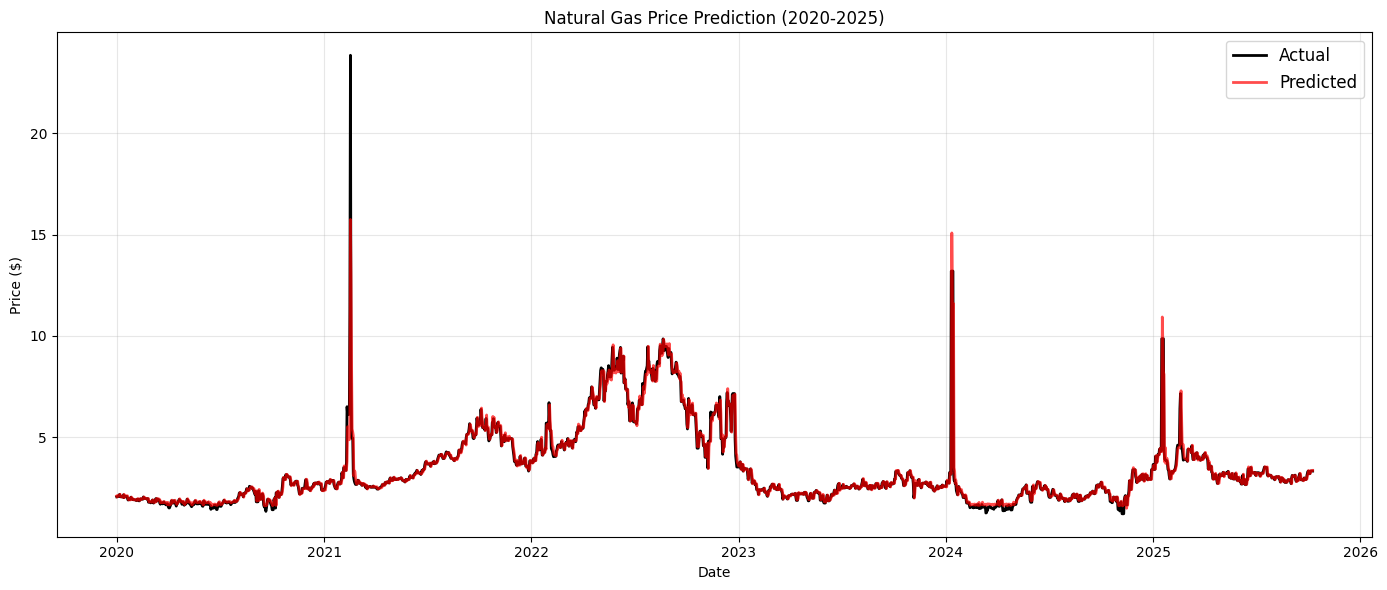

In [452]:
preds = model.predict(X_test_scaled)

plt.figure(figsize=(14, 6))
plt.plot(test['date'], y_test, label='Actual', color='black', linewidth=2)
plt.plot(test['date'], preds, label='Predicted', color='red', alpha=0.7, linewidth=2)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.title('Natural Gas Price Prediction (2020-2025)')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [453]:
# Create results dataframe
results = pd.DataFrame({
    'date': test['date'].shift(-1),
    'actual_price': y_test,
    'predicted_price': preds,
})

In [454]:
from sklearn.metrics import mean_squared_error
results = results.dropna()
mse = mean_squared_error(results['actual_price'], results['predicted_price'])
rmse = mse ** 0.5
score = 1 / (1 + rmse)
print(score)

0.6721462095952232


## Save the results

In [436]:
results[["date", "predicted_price"]].rename(columns={"date": "id", "predicted_price": "price_usd_per_mmbtu"}).to_csv("results.csv", index=False)